# IA aplicada ao Agronegocio - Recomendacao de Culturas

**Grupo:**

| Nome | RM | GitHub |
| --- | --- | --- |
| Henrique Sanches Silva | RM570527 | @HenriqueSanchesSilva |
| Luis Henrique Laurentino Boschi | RM571352 | @lhboschi |
| Kayck Gabriel Evangelista da Silva | RM572331 | @Kayckxz |
| Patrick Borges de Melo | RM574030 | @Trickmelo |
| Joao Pedro Zavanela Andreu | RM570231 | @zjpza |

**Disciplina:** Fase 3 - Capitulo 10 - A primeira tecnica de aprendizado de maquina

Este notebook apresenta a analise exploratoria da base de produtos agricolas, a construcao de visualizacoes descritivas, a comparacao do perfil de solo e clima de tres culturas e o treinamento de cinco modelos de classificacao supervisionada para recomendar a cultura mais adequada de acordo com as condicoes ambientais observadas.

## Organizacao do notebook

1. Carregamento e verificacao da base.
2. Analise exploratoria com estatisticas descritivas.
3. Analise descritiva com pelo menos cinco visualizacoes.
4. Perfil de solo e clima para tres culturas escolhidas.
5. Preparacao dos dados para Machine Learning.
6. Treinamento e comparacao de cinco algoritmos.
7. Conclusoes, pontos fortes e limitacoes.

In [43]:
# Imports do projeto
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
    )
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42

In [44]:
# Carregamento da base
base_dir = Path.cwd()
csv_candidates = [
    base_dir / "Atividade_Cap10_produtos_agricolas.csv",
    base_dir / "src" / "Atividade_Cap10_produtos_agricolas.csv",
    Path("Atividade_Cap10_produtos_agricolas.csv"),  
]
csv_path = next((path for path in csv_candidates if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError("Nao foi possivel localizar o arquivo Atividade_Cap10_produtos_agricolas.csv")

df = pd.read_csv(csv_path)
print(f"Dataset carregado de: {csv_path.name}")
print(f"Dimensoes: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dataset carregado de: Atividade_Cap10_produtos_agricolas.csv
Dimensoes: 2200 linhas x 8 colunas


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 1. Analise exploratoria do dataset

A base possui informacoes de nutricao do solo, temperatura, umidade, pH e chuva para 22 culturas agricolas. Nesta etapa, verificamos dimensoes, tipos, ausencia de nulos e duplicados e o comportamento estatistico geral das variaveis. Essas verificacoes sao importantes para confirmar se o conjunto esta pronto para a modelagem.

In [45]:
# Visao geral da base
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
print()
print("Tipos de dados:")
print(df.dtypes)
print()
print("Valores nulos por coluna:")
print(df.isnull().sum())
print()
print(f"Linhas duplicadas: {df.duplicated().sum()}")
print()

display(df.describe().T.round(2))

Linhas: 2200
Colunas: 8

Tipos de dados:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

Valores nulos por coluna:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Linhas duplicadas: 0



,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.55,36.92,0.00,21.00,37.00,84.25,140.00
P,2200.0,53.36,32.99,5.00,28.00,51.00,68.00,145.00
K,2200.0,48.15,50.65,5.00,20.00,32.00,49.00,205.00
temperature,2200.0,25.62,5.06,8.83,22.77,25.60,28.56,43.68
humidity,2200.0,71.48,22.26,14.26,60.26,80.47,89.95,99.98
ph,2200.0,6.47,0.77,3.50,5.97,6.43,6.92,9.94
rainfall,2200.0,103.46,54.96,20.21,64.55,94.87,124.27,298.56


## 2. Analise descritiva com graficos

A base esta limpa, com 2.200 registros e 22 culturas. Como cada cultura aparece 100 vezes, o problema e balanceado, o que reduz o risco de vies forte nas metricas. A seguir, sao apresentados cinco conjuntos de graficos para interpretar a distribuicao das classes, a dispersao das variaveis numericas, a presenca de outliers, as correlacoes e as diferencas entre culturas.

Numero de culturas distintas: 22
Contagem por cultura (deve ser uniforme):


label
apple          100
banana         100
blackgram      100
chickpea       100
coconut        100
coffee         100
cotton         100
grapes         100
jute           100
kidneybeans    100
lentil         100
maize          100
mango          100
mothbeans      100
mungbean       100
muskmelon      100
orange         100
papaya         100
pigeonpeas     100
pomegranate    100
rice           100
watermelon     100
Name: count, dtype: int64

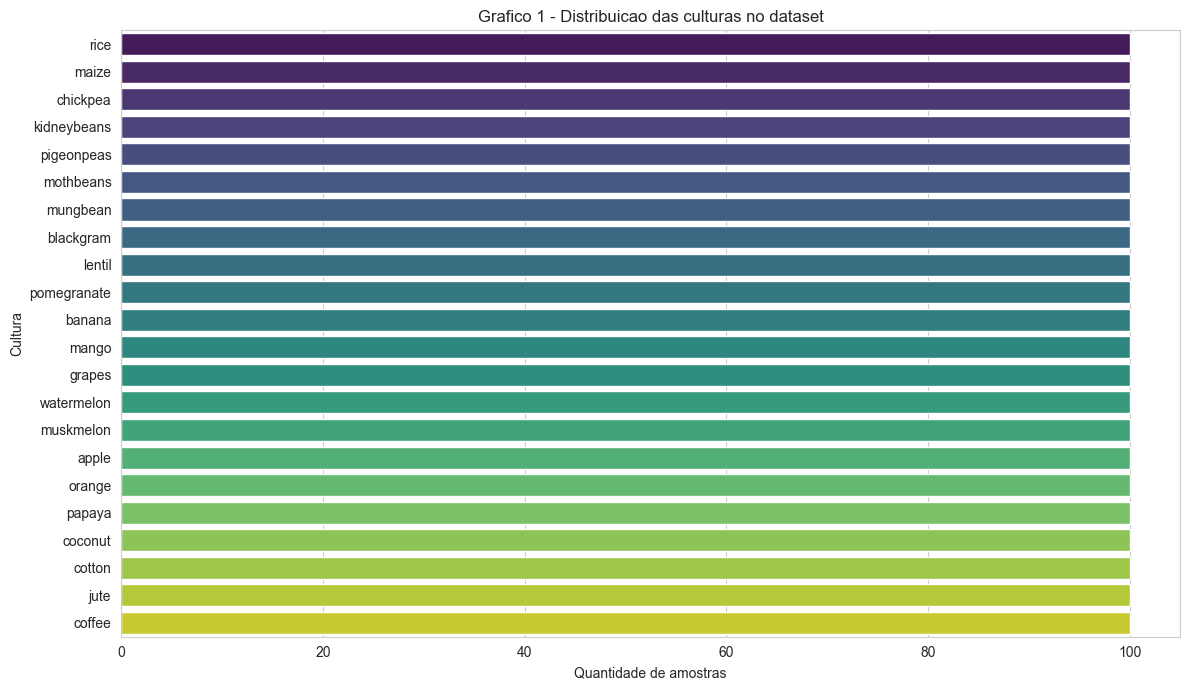

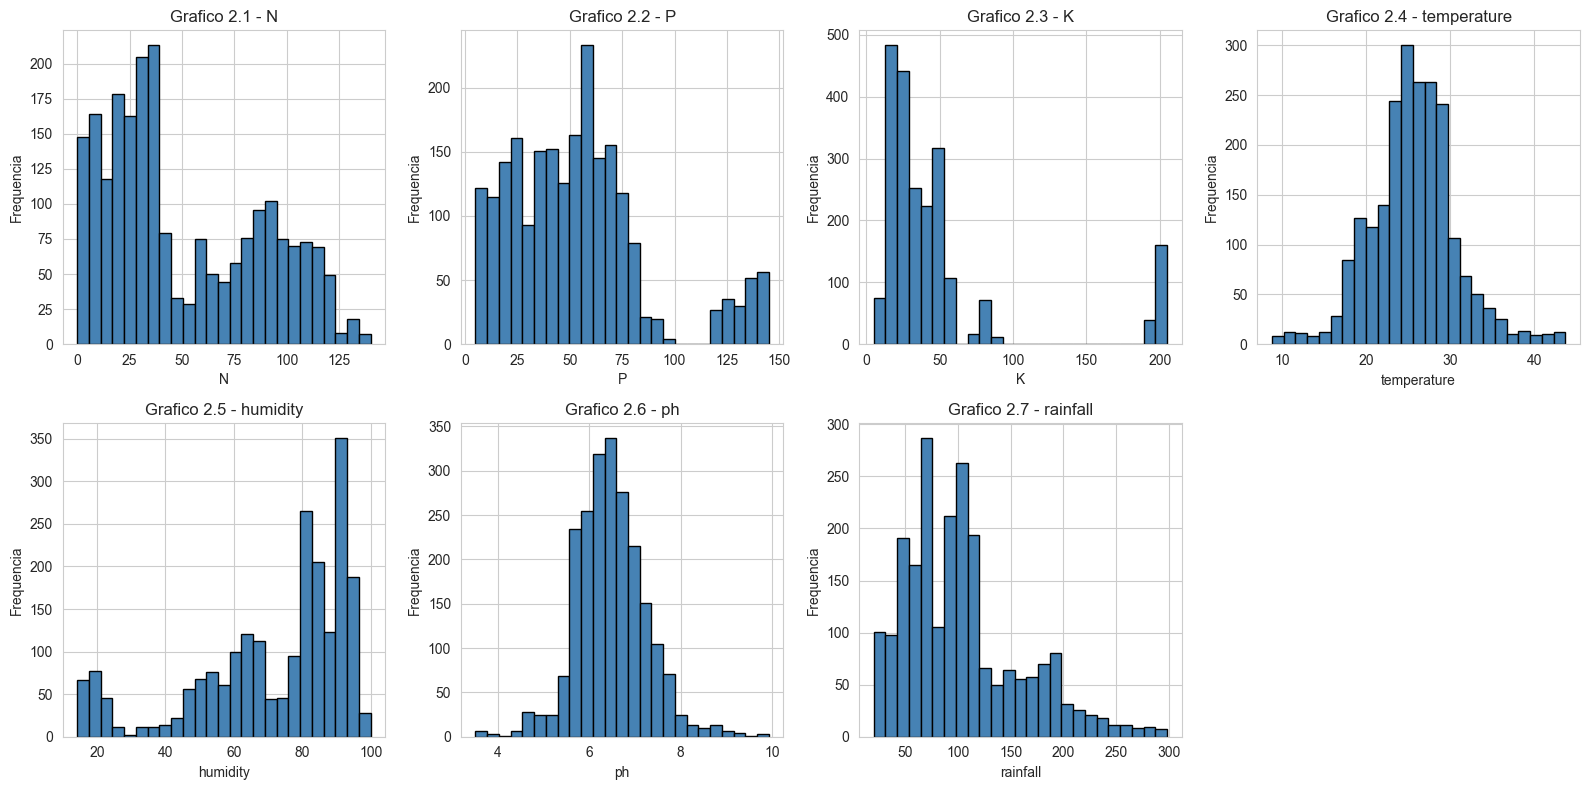

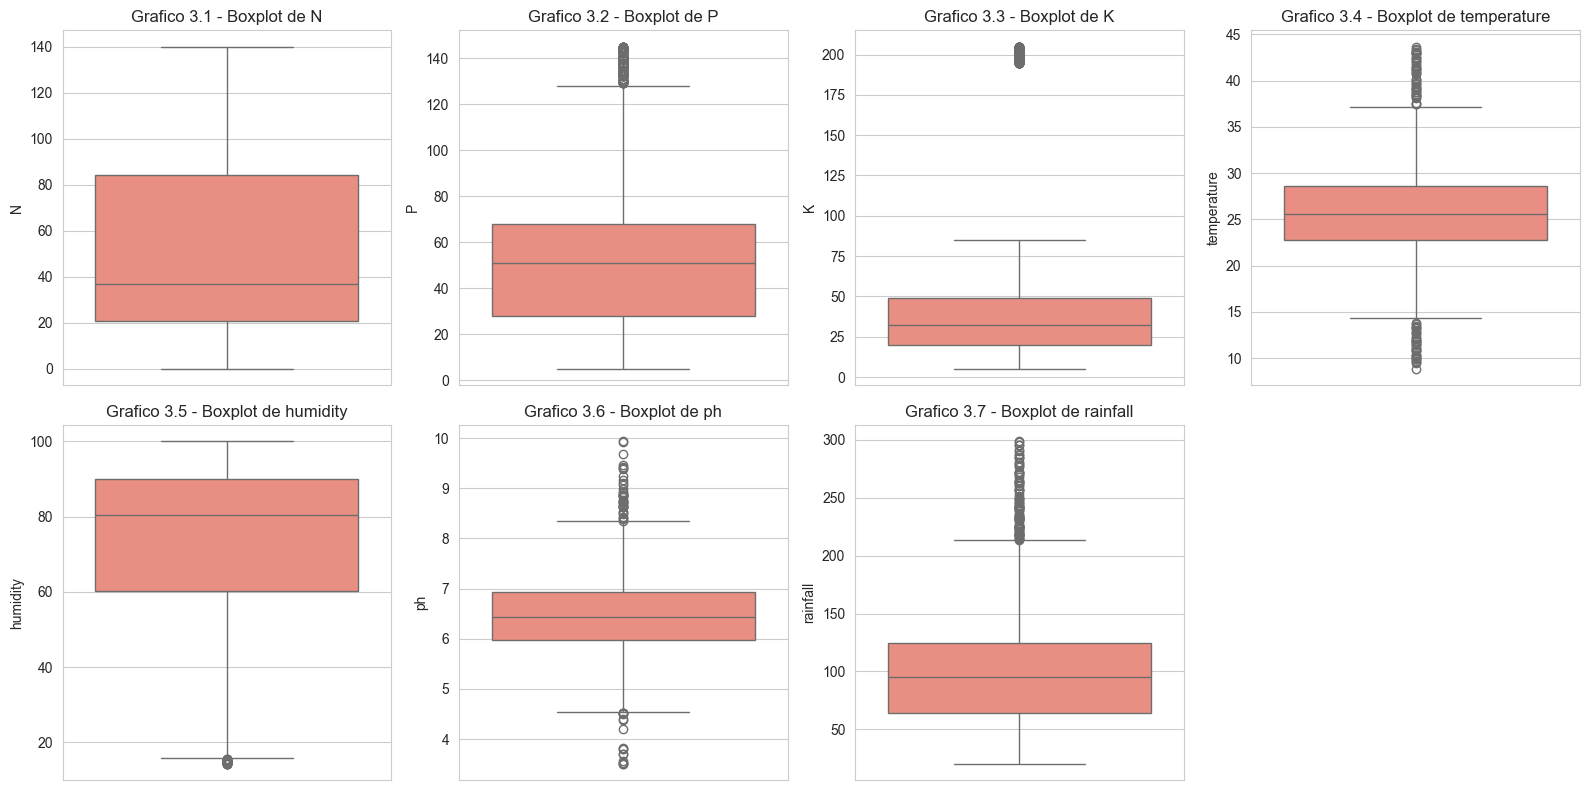

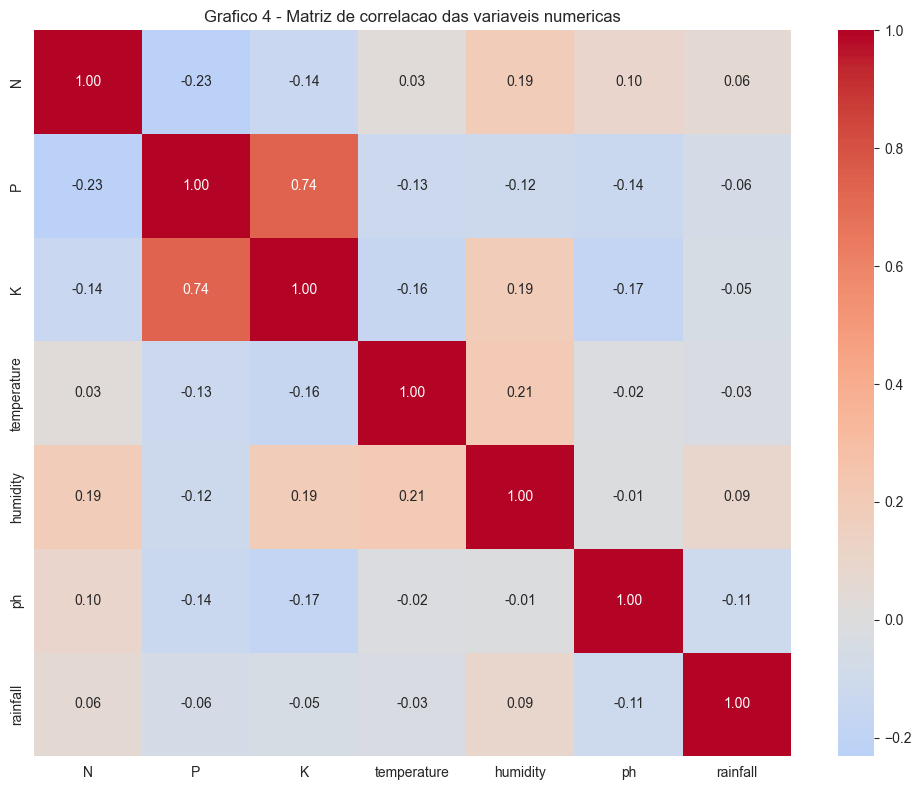

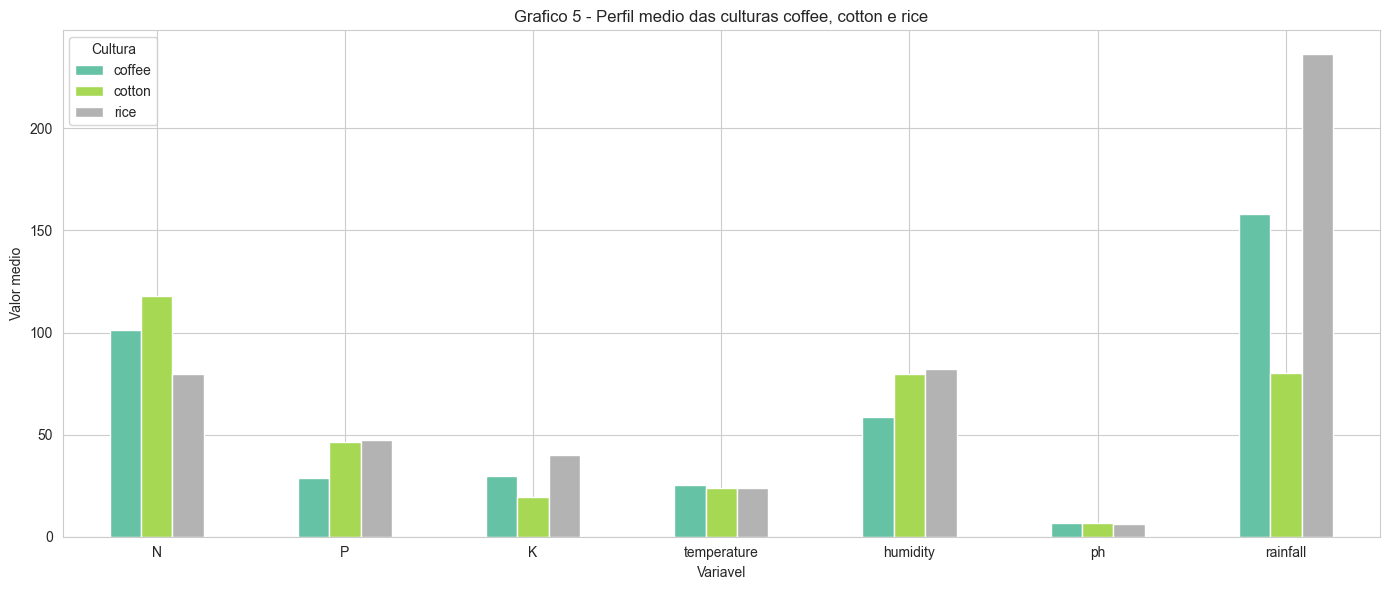

In [46]:
features_num = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

print(f"Numero de culturas distintas: {df['label'].nunique()}")
print("Contagem por cultura (deve ser uniforme):")
display(df['label'].value_counts().sort_index())

# Grafico 1: distribuicao das classes
plt.figure(figsize=(12, 7))
ordem = df['label'].value_counts().index
sns.countplot(data=df, y='label', order=ordem, palette='viridis')
plt.title('Grafico 1 - Distribuicao das culturas no dataset')
plt.xlabel('Quantidade de amostras')
plt.ylabel('Cultura')
plt.tight_layout()
plt.show()

# Grafico 2: histogramas das features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(features_num):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Grafico 2.{i+1} - {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequencia')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

# Grafico 3: boxplots para outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(features_num):
    sns.boxplot(y=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Grafico 3.{i+1} - Boxplot de {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

# Grafico 4: matriz de correlacao
plt.figure(figsize=(10, 8))
sns.heatmap(df[features_num].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Grafico 4 - Matriz de correlacao das variaveis numericas')
plt.tight_layout()
plt.show()

# Grafico 5: medias das features por tres culturas
culturas_escolhidas = ['coffee', 'cotton', 'rice']
perfil_culturas_plot = df[df['label'].isin(culturas_escolhidas)].groupby('label')[features_num].mean().T
perfil_culturas_plot.plot(kind='bar', figsize=(14, 6), colormap='Set2')
plt.title('Grafico 5 - Perfil medio das culturas coffee, cotton e rice')
plt.xlabel('Variavel')
plt.ylabel('Valor medio')
plt.xticks(rotation=0)
plt.legend(title='Cultura')
plt.tight_layout()
plt.show()

## 3. Perfil ideal de solo e clima

Para esta etapa, adotamos a media geral do dataset como referencia inicial de perfil medio de cultivo. Em seguida, foram selecionadas tres culturas com caracteristicas distintas - `coffee`, `cotton` e `rice` - para verificar como variam as exigencias de nutrientes e clima. O objetivo nao e afirmar um perfil ideal unico para toda a agricultura, mas identificar padroes medios que ajudem a compreender quais combinacoes de fatores favorecem culturas especificas.

Perfil medio geral do dataset:


,media_geral
N,50.55
P,53.36
K,48.15
temperature,25.62
humidity,71.48
ph,6.47
rainfall,103.46


Perfil medio das culturas escolhidas:


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
coffee,101.20,28.74,29.94,25.54,58.87,6.79,158.07
cotton,117.77,46.24,19.56,23.99,79.84,6.91,80.40
rice,79.89,47.58,39.87,23.69,82.27,6.43,236.18


label,coffee,cotton,rice,media_geral
N,101.20,117.77,79.89,50.55
P,28.74,46.24,47.58,53.36
K,29.94,19.56,39.87,48.15
temperature,25.54,23.99,23.69,25.62
humidity,58.87,79.84,82.27,71.48
ph,6.79,6.91,6.43,6.47
rainfall,158.07,80.40,236.18,103.46


Desvio em relacao a media geral do dataset:


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
coffee,50.65,-24.62,-18.21,-0.08,-12.61,0.32,54.61
cotton,67.22,-7.12,-28.59,-1.63,8.36,0.44,-23.06
rice,29.34,-5.78,-8.28,-1.93,10.79,-0.04,132.72


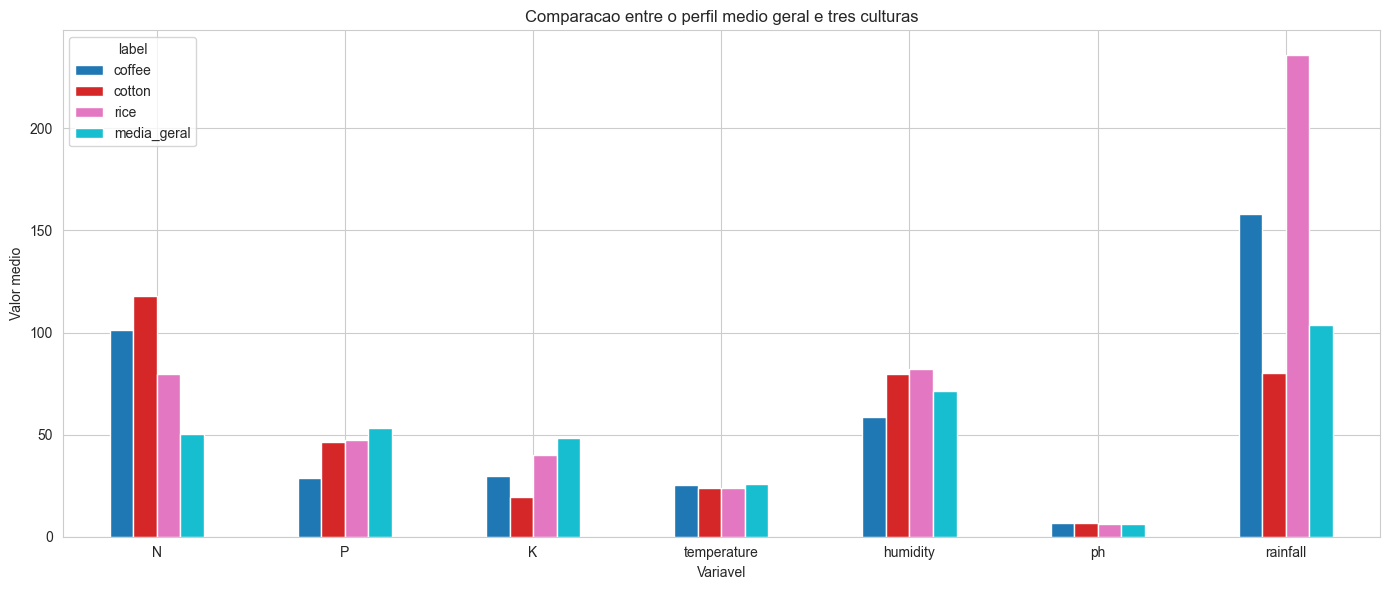

In [47]:
features_num = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
culturas_escolhidas = ['coffee', 'cotton', 'rice']

perfil_medio_geral = df[features_num].mean().round(2).rename('media_geral')
perfil_culturas = (
    df[df['label'].isin(culturas_escolhidas)]
    .groupby('label')[features_num]
    .mean()
    .round(2)
    )

print('Perfil medio geral do dataset:')
display(perfil_medio_geral.to_frame())
print('Perfil medio das culturas escolhidas:')
display(perfil_culturas)

comparacao_perfis = perfil_culturas.T.copy()
comparacao_perfis['media_geral'] = perfil_medio_geral
display(comparacao_perfis)

desvios = (perfil_culturas.sub(perfil_medio_geral, axis=1)).round(2)
print('Desvio em relacao a media geral do dataset:')
display(desvios)

ax = comparacao_perfis.plot(kind='bar', figsize=(14, 6), colormap='tab10')
ax.set_title('Comparacao entre o perfil medio geral e tres culturas')
ax.set_xlabel('Variavel')
ax.set_ylabel('Valor medio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretacao da comparacao entre culturas

A leitura dos resultados indica que `rice` e a cultura mais dependente de agua entre as tres analisadas, apresentando umidade media de 82,27 e precipitacao media de 236,18 mm, ambas bem acima da media geral do dataset. Em contraste, `cotton` apresenta alta demanda por nitrogenio e fosforo, mas chuva media de apenas 80,40 mm. O que sugere adaptacao a contextos com menor disponibilidade hidrica. Ja `coffee` combina alta necessidade de nitrogenio com chuva intermediaria e umidade abaixo de `rice`, mantendo pH levemente acima da media do conjunto.

Essas diferencas mostram que o chamado perfil ideal deve ser interpretado como um perfil ideal por cultura, e nao como um unico padrao universal. Sob a perspectiva agronomica e estatistica, a comparacao evidencia que chuva e umidade sao fatores particularmente discriminantes entre as culturas escolhidas, enquanto N, P e K refinam a separacao conforme a necessidade nutricional de cada plantio.

## 4. Preparacao para modelagem

Como a variavel alvo e categorica, aplicamos o LabelEncoder porque ele transforma os nomes das culturas em numeros. Em seguida, os dados foram divididos em treino e teste com estratificacao para manter o balanceamento entre as 22 classes. Por fim, usamos MinMaxScaler, especialmente importante para KNN e SVM, que sao algoritmos sensiveis a escala das features.

In [48]:
X = df.drop(columns='label')
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
    )

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")
print(f"Numero de classes: {len(le.classes_)}")
print()
print('Exemplo de mapeamento do target:')
for indice, classe in enumerate(le.classes_[:10]):
    print(f"{indice} -> {classe}")

Treino: 1760 amostras
Teste: 440 amostras
Numero de classes: 22

Exemplo de mapeamento do target:
0 -> apple
1 -> banana
2 -> blackgram
3 -> chickpea
4 -> coconut
5 -> coffee
6 -> cotton
7 -> grapes
8 -> jute
9 -> kidneybeans


## 5. Modelos preditivos

Foram treinados cinco algoritmos de classificacao supervisionada: Regressao Logistica, KNN, Decision Tree, Random Forest e SVM. No caso do SVM, foram testados tres kernels e foi mantido o kernel RBF, que apresentou o melhor desempenho entre as variantes avaliadas. As metricas consideradas foram acuracia, precisao, recall e F1-score ponderado.

In [49]:
modelos = {
    'Regressao Logistica': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=9),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

resultados = []
predicoes = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    predicoes[nome] = y_pred
    resultados.append({
        'Modelo': nome,
        'Acuracia': accuracy_score(y_test, y_pred),
        'Precisao': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-score': f1_score(y_test, y_pred, average='weighted'),
    })

svm_resultados = []
for kernel in ['linear', 'poly', 'rbf']:
    svm = SVC(kernel=kernel, random_state=RANDOM_STATE)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    svm_resultados.append({
        'kernel': kernel,
        'Acuracia': accuracy_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred, average='weighted'),
    })

svm_resultados_df = pd.DataFrame(svm_resultados).sort_values(by='Acuracia', ascending=False)
display(svm_resultados_df.round(4))

melhor_kernel = svm_resultados_df.iloc[0]['kernel']
svm_final = SVC(kernel=melhor_kernel, random_state=RANDOM_STATE)
svm_final.fit(X_train_scaled, y_train)
y_pred_svm = svm_final.predict(X_test_scaled)
predicoes[f'SVM ({melhor_kernel})'] = y_pred_svm
resultados.append({
    'Modelo': f'SVM ({melhor_kernel})',
    'Acuracia': accuracy_score(y_test, y_pred_svm),
    'Precisao': precision_score(y_test, y_pred_svm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_svm, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, y_pred_svm, average='weighted'),
})

resultados_df = pd.DataFrame(resultados).sort_values(by='Acuracia', ascending=False).reset_index(drop=True)
display(resultados_df.round(4))

,kernel,Acuracia,F1-score
2,rbf,0.9864,0.9863
1,poly,0.9841,0.9840
0,linear,0.9636,0.9633


,Modelo,Acuracia,Precisao,Recall,F1-score
0,Random Forest,0.9955,0.9957,0.9955,0.9955
1,SVM (rbf),0.9864,0.9881,0.9864,0.9863
2,Decision Tree,0.9795,0.9806,0.9795,0.9794
3,KNN,0.9795,0.9810,0.9795,0.9794
4,Regressao Logistica,0.9409,0.9464,0.9409,0.9404


## 6. Avaliacao e comparacao dos modelos

Os resultados mostram um problema altamente separavel. Mesmo os modelos mais simples tiveram desempenho elevado, enquanto o Random Forest apresentou a melhor performance geral, com acuracia proxima de 99,5 por cento. Isso sugere que a combinacao de nutrientes, umidade e chuva fornece sinais fortes para diferenciar as culturas.

,Modelo,Acuracia,Precisao,Recall,F1-score
0,Random Forest,0.9955,0.9957,0.9955,0.9955
1,SVM (rbf),0.9864,0.9881,0.9864,0.9863
2,Decision Tree,0.9795,0.9806,0.9795,0.9794
3,KNN,0.9795,0.9810,0.9795,0.9794
4,Regressao Logistica,0.9409,0.9464,0.9409,0.9404


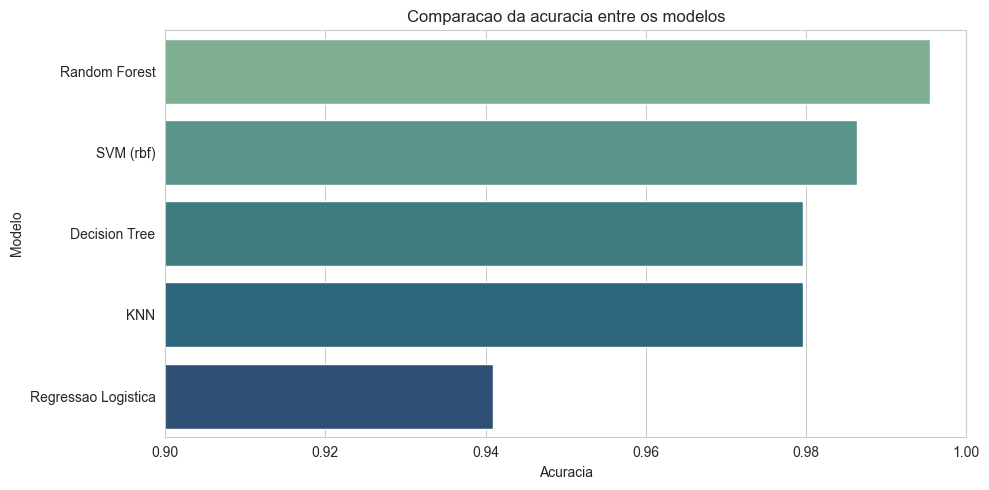

Melhor modelo: Random Forest

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        

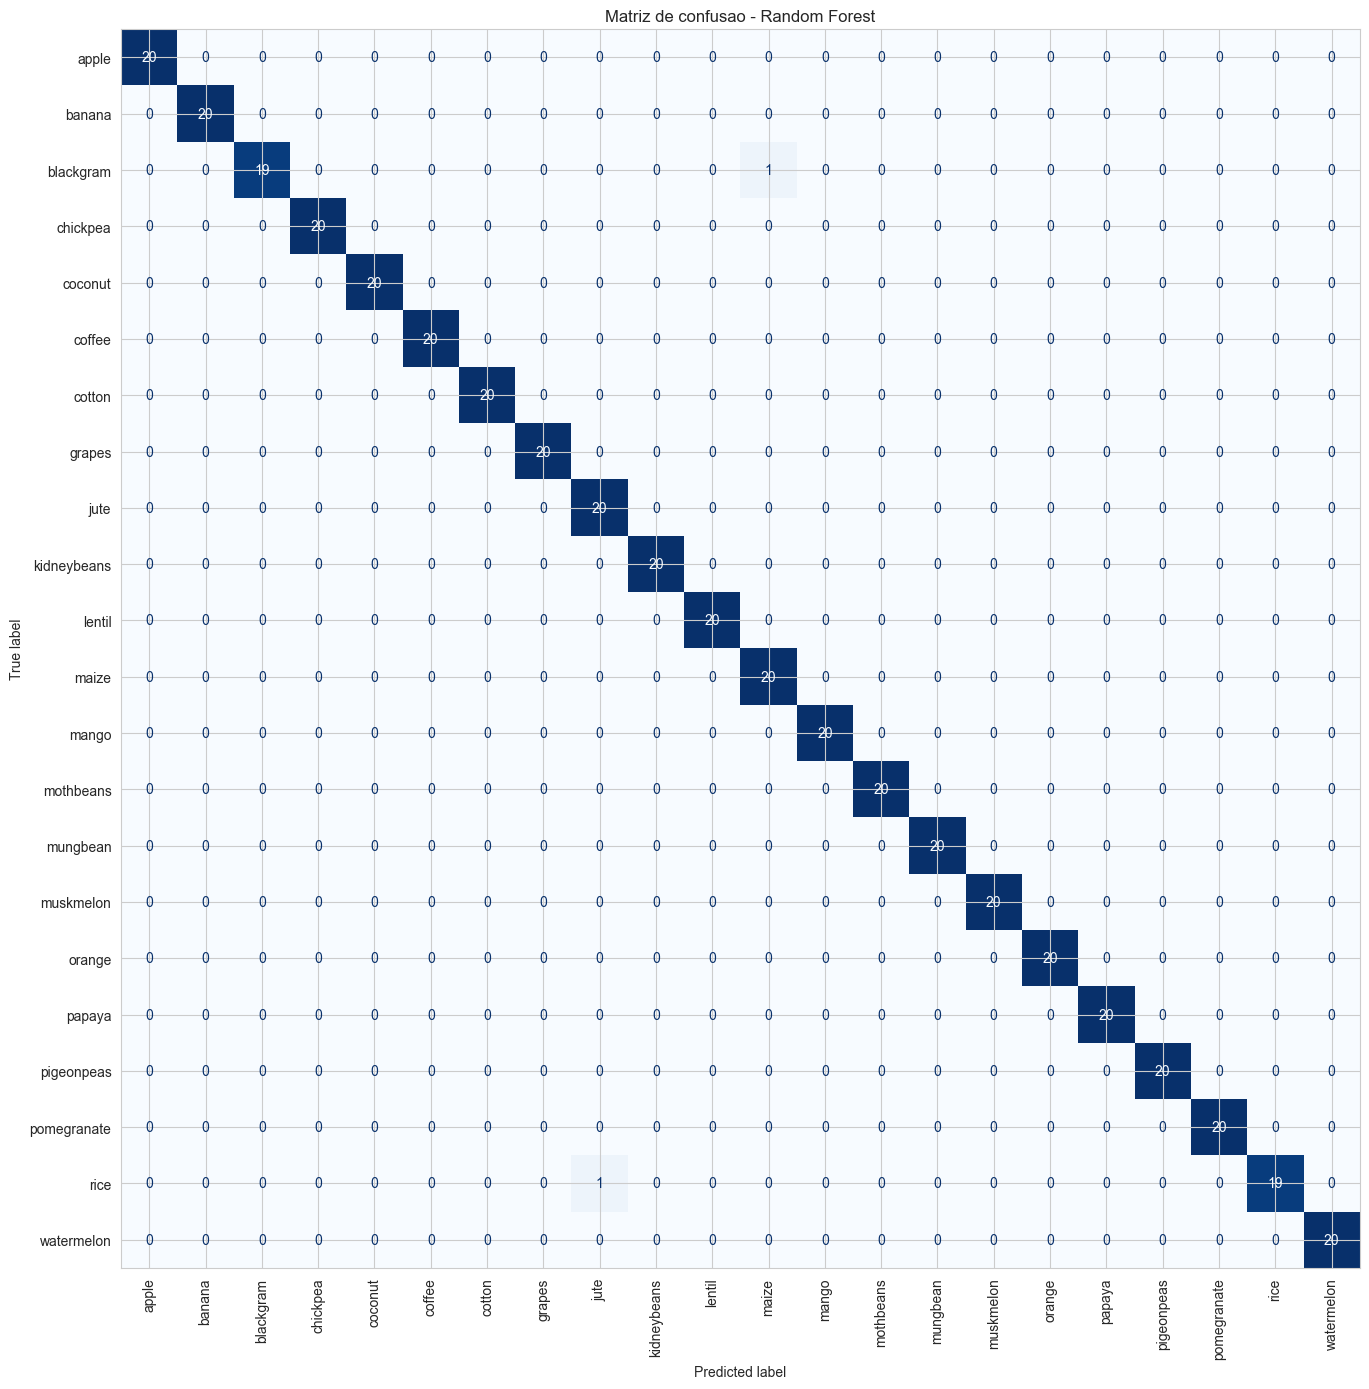

,Feature,Importancia
6,rainfall,0.2196
4,humidity,0.2171
2,K,0.1808
1,P,0.1513
0,N,0.1034
3,temperature,0.0755
5,ph,0.0523


In [50]:
display(resultados_df.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=resultados_df, x='Acuracia', y='Modelo', palette='crest')
plt.title('Comparacao da acuracia entre os modelos')
plt.xlim(0.90, 1.0)
plt.tight_layout()
plt.show()

melhor_modelo_nome = resultados_df.iloc[0]['Modelo']
melhor_pred = predicoes[melhor_modelo_nome]
print(f"Melhor modelo: {melhor_modelo_nome}")
print()
print(classification_report(y_test, melhor_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, melhor_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(14, 14))
disp.plot(ax=ax, xticks_rotation=90, cmap='Blues', colorbar=False)
plt.title(f'Matriz de confusao - {melhor_modelo_nome}')
plt.tight_layout()
plt.show()

if melhor_modelo_nome == 'Random Forest':
    importancias = pd.DataFrame({
        'Feature': X.columns,
        'Importancia': modelos['Random Forest'].feature_importances_,
    }).sort_values(by='Importancia', ascending=False)
    display(importancias.round(4))

## 7. Conclusoes

A analise exploratoria mostrou que o dataset esta limpo, balanceado e adequado para um problema multiclasses. As variaveis rainfall, humidity, K e P foram as que mais ajudaram o melhor modelo a diferenciar culturas, o que faz sentido porque disponibilidade de agua e composicao do solo influenciam diretamente o cultivo. Entre as culturas analisadas, rice se destacou por exigir alta umidade e alta precipitacao, coffee apresentou maior necessidade de nitrogeneo e chuva intermediaria, e cotton mostrou perfil de alta umidade com chuva bem menor que rice.

Nos testes preditivos, o Random Forest foi o melhor modelo, com desempenho superior aos demais, seguido de perto pelo SVM com kernel RBF, pelo KNN e pela Decision Tree. A Regressao Logistica foi a mais fraca do grupo, embora ainda tenha apresentado resultado forte, o que indica que a base tem padroes bem definidos. Como limitacoes, o estudo usa apenas um recorte de dados e uma unica divisao treino-teste, sem validacao cruzada nem ajuste fino de hiperparametros. Em uma evolucao futura, seria recomendavel testar tecnicas de tuning, validacao cruzada e algoritmos mais avancados, como XGBoost.